In [2]:
import tensorflow as tf
from importlib import reload
import pandas as pd
import numpy as np
from pathlib import Path
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [3]:
raw_train_set, raw_valid_set, raw_test_set = tfds.load(
    name="imdb_reviews",
    split=["train[:90%]", "train[90%:]", "test"],
    as_supervised=True
)

tf.random.set_seed(42)
train_set = raw_train_set.shuffle(5000, seed=42).batch(32).prefetch(1)
valid_set = raw_valid_set.batch(32).prefetch(1)
test_set = raw_test_set.batch(32).prefetch(1)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.9QF2ZT_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.9QF2ZT_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.9QF2ZT_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.


In [4]:
vocab_size = 1000
text_vec_layer = tf.keras.layers.TextVectorization(max_tokens=vocab_size)
text_vec_layer.adapt(train_set.map(lambda reviews, labels: reviews))

In [13]:
embed_size = 128
tf.random.set_seed(42)

def left_pad(inp):
    x = tf.reverse_sequence(
        inp,
        seq_lengths=tf.reduce_sum(tf.cast(inp != 0, tf.int32), axis=1),
        seq_axis=1
    )

    return tf.reverse(x, axis=[-1])

model = tf.keras.Sequential([
    text_vec_layer,
    tf.keras.layers.Lambda(left_pad),
    tf.keras.layers.Embedding(vocab_size, embed_size),
    tf.keras.layers.GRU(128),
    tf.keras.layers.Dense(1, activation="sigmoid")
])
model.compile(loss="binary_crossentropy", optimizer="nadam", metrics=["accuracy"])
history = model.fit(train_set, validation_data=valid_set, epochs=3)

Epoch 1/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 38ms/step - accuracy: 0.6379 - loss: 0.6294 - val_accuracy: 0.8132 - val_loss: 0.4173
Epoch 2/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.8468 - loss: 0.3592 - val_accuracy: 0.8708 - val_loss: 0.3123
Epoch 3/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 36ms/step - accuracy: 0.8766 - loss: 0.2953 - val_accuracy: 0.8668 - val_loss: 0.3104


In [10]:
model.layers

[<TextVectorization name=text_vectorization, built=False>,
 <Lambda name=lambda_1, built=False>,
 <Embedding name=embedding_1, built=False>,
 <GRU name=gru_1, built=False>,
 <Dense name=dense_1, built=False>]

In [14]:
emb_mat = model.layers[2].get_weights()[0]
emb_mat

array([[ 0.18838309,  0.08516396, -0.07502581, ...,  0.27949458,
         0.05965941,  0.0847801 ],
       [-0.0303874 , -0.00635273,  0.00588911, ...,  0.05348082,
         0.01903329, -0.06950718],
       [-0.06051219,  0.01782956, -0.06342832, ...,  0.06361088,
         0.00832406, -0.03552169],
       ...,
       [ 0.05942524,  0.02066308, -0.00660719, ...,  0.18839675,
        -0.02107712, -0.06756256],
       [ 0.0386138 ,  0.16949552,  0.15453237, ..., -0.24328129,
        -0.15382889,  0.18087889],
       [-0.04941433,  0.07774474,  0.04405699, ..., -0.09470091,
        -0.12546179,  0.04653736]], dtype=float32)

In [15]:
type(emb_mat)
emb_mat.shape

(1000, 128)

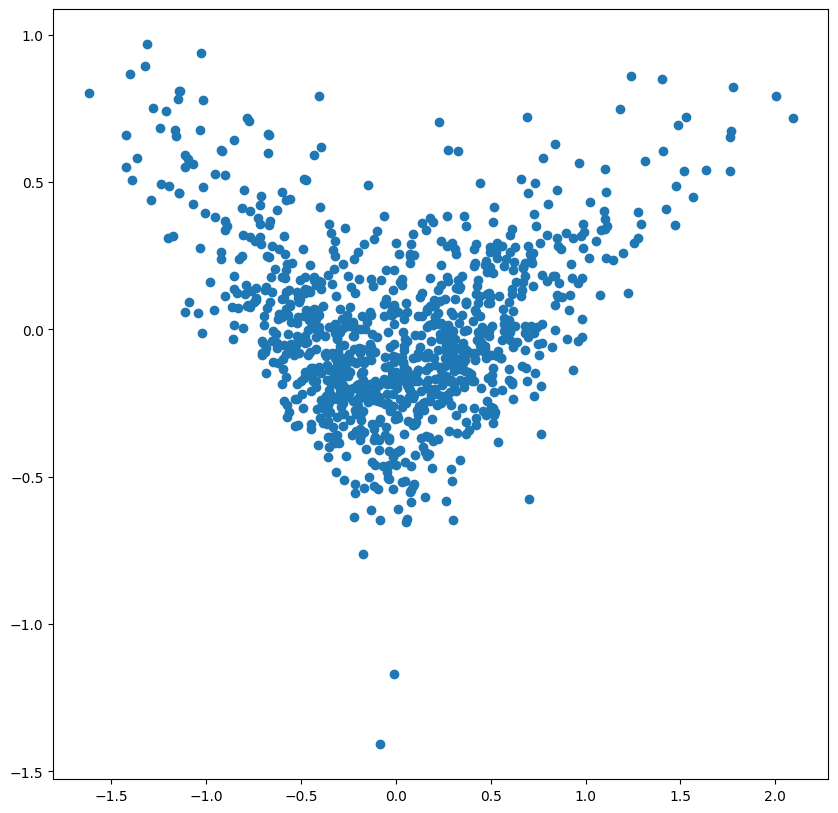

In [16]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

tsne = PCA(n_components=2, random_state=42)
reduced = tsne.fit_transform(emb_mat)

plt.figure(figsize=(10,10))
plt.scatter(reduced[:,0], reduced[:,1])

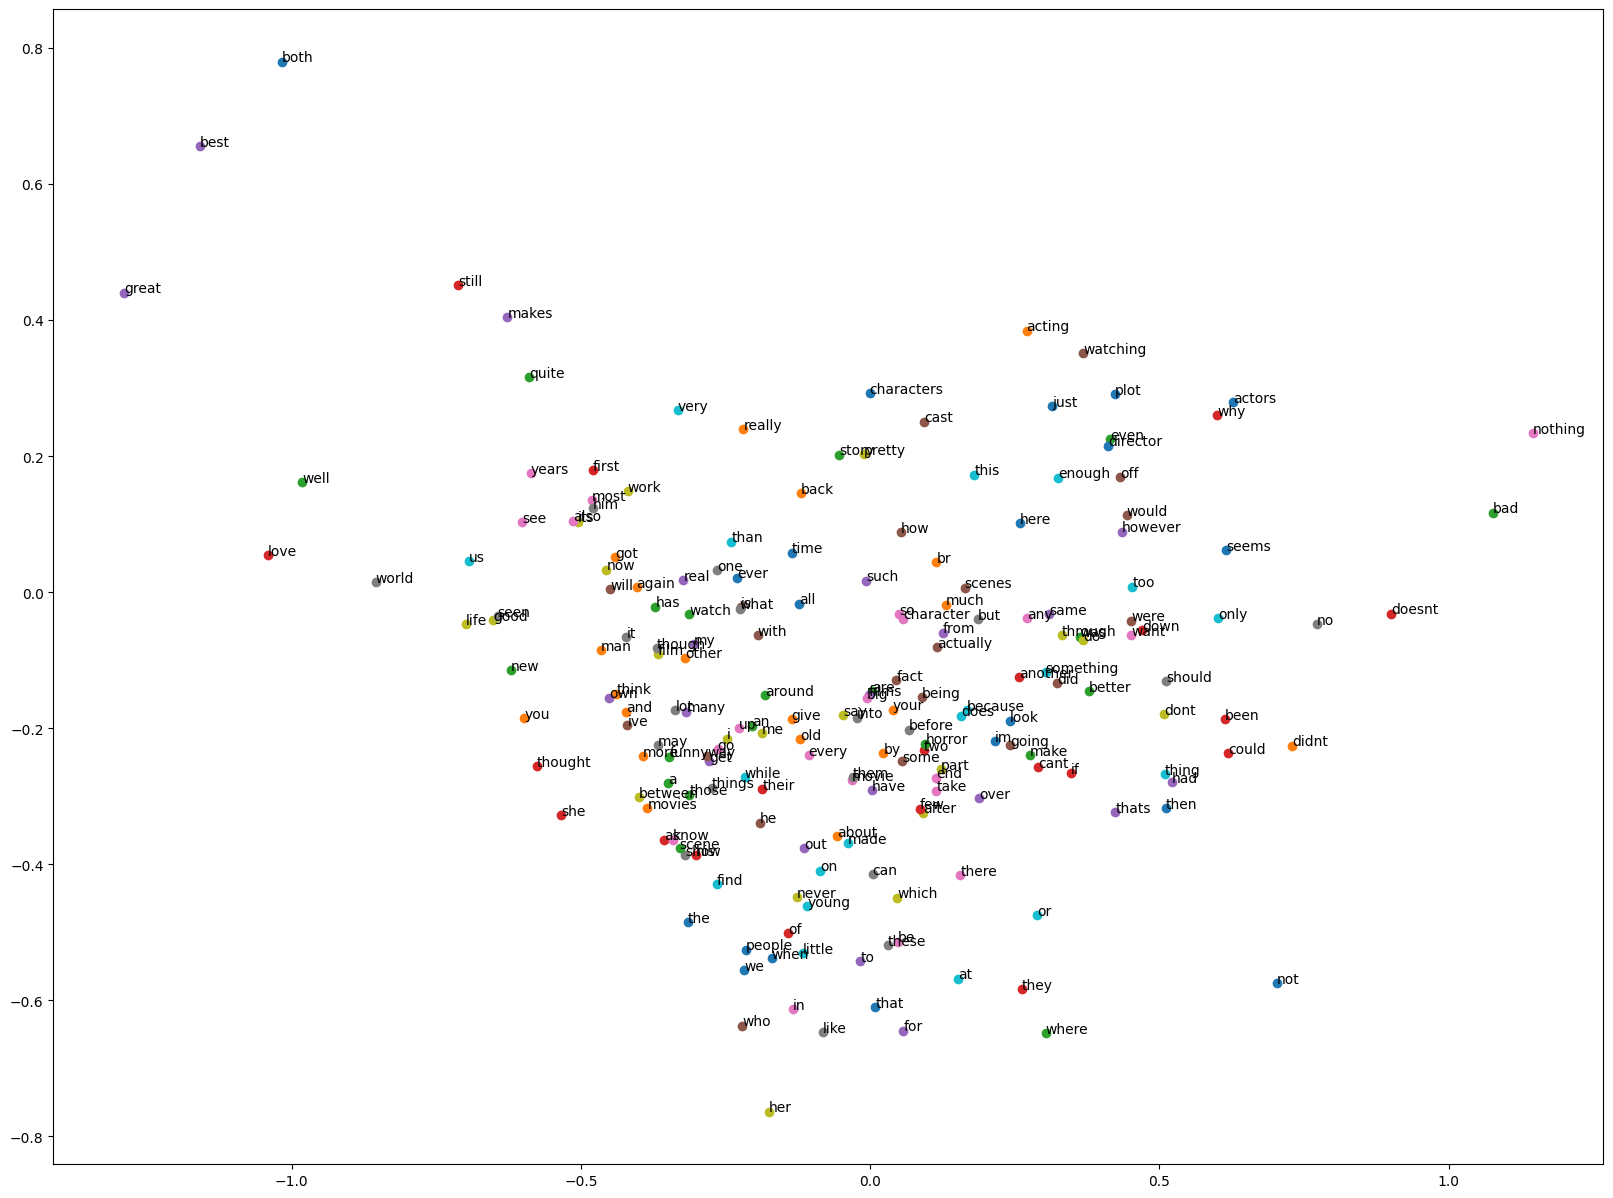

In [21]:
plt.figure(figsize=(20,15))

for i, word in enumerate(text_vec_layer.get_vocabulary()[2:200], start=2):
    plt.scatter(reduced[i,0], reduced[i,1])
    plt.text(reduced[i,0], reduced[i,1], word)

plt.show()